# Credit Card Spending Analysis by Category

**Tools:** Python, Pandas, NumPy and Matplotlib

**Workflow:** Raw CSV → Data Understanding → Data Cleaning → Cleaned CSV → Analysis → Visualization → SQL → Power BI

The raw CSV is kept unchanged. All cleaning is performed in this notebook, and the cleaned result is saved as a separate CSV file.

## 1. Import Libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Raw CSV

The notebook starts with the raw transaction file. The cleaned file is created later in the notebook.

In [7]:
raw_path = "../01_Data/Credit_Card_Transactions_Raw.csv"
df = pd.read_csv(raw_path)

print("Raw data loaded successfully")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
df.head()

Raw data loaded successfully
Rows: 26052
Columns: 7


,index,City,Date,Card Type,Exp Type,Gender,Amount
0,0,"Delhi, India",29-Oct-14,Gold,Bills,F,82475
1,1,"Greater Mumbai, India",22-Aug-14,Platinum,Bills,F,32555
2,2,"Bengaluru, India",27-Aug-14,Silver,Bills,F,101738
3,3,"Greater Mumbai, India",12-Apr-14,Signature,Bills,F,123424
4,4,"Bengaluru, India",5-May-15,Gold,Bills,F,171574


## 3. Data Understanding

In [8]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nBasic statistics:")
df.describe(include="all").T

Shape: (26052, 7)

Columns:
['index', 'City', 'Date', 'Card Type', 'Exp Type', 'Gender', 'Amount']

Data types:
index         int64
City         object
Date         object
Card Type    object
Exp Type     object
Gender       object
Amount        int64
dtype: object

Missing values:
index        0
City         0
Date         0
Card Type    0
Exp Type     0
Gender       0
Amount       0
dtype: int64

Duplicate rows: 0

Basic statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
index,26052.0,NaN,NaN,NaN,13025.5,7520.708943,0.0,6512.75,13025.5,19538.25,26051.0
City,26052,986,"Bengaluru, India",3552,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date,26052,600,20-Sep-14,65,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Card Type,26052,4,Silver,6840,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Exp Type,26052,6,Food,5463,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,26052,2,F,13680,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Amount,26052.0,NaN,NaN,NaN,156411.537425,103063.254287,1005.0,77120.25,153106.5,228050.0,998077.0


## 4. Data Cleaning

Cleaning steps: column names, duplicate rows, data types, invalid dates/amounts, missing required values, and simple text standardization.

In [9]:
# Clean column names
df.columns = (
    df.columns.str.strip()
    .str.replace(" ", "_", regex=False)
)

# Rename columns in the cleaned data for clear analysis
rename_map = {}
if "index" in df.columns:
    rename_map["index"] = "Transaction_ID"
if "Exp_Type" in df.columns:
    rename_map["Exp_Type"] = "Expense_Type"
df = df.rename(columns=rename_map)

# Remove duplicate rows
before_duplicates = len(df)
df = df.drop_duplicates().copy()
print("Duplicate rows removed:", before_duplicates - len(df))

# Correct data types
df["Date"] = pd.to_datetime(df["Date"], format="%d-%b-%y", errors="coerce")
df["Amount"] = pd.to_numeric(df["Amount"], errors="coerce")

# Standardize text values
df["Gender"] = df["Gender"].replace({"F": "Female", "M": "Male"})
df["City"] = df["City"].str.replace("Greater Mumbai", "Mumbai", regex=False)

# Remove rows with invalid or missing required values
before_invalid = len(df)
required_columns = [
    "Transaction_ID", "City", "Date", "Card_Type",
    "Expense_Type", "Gender", "Amount"
]
df = df.dropna(subset=required_columns).copy()
df = df[df["Amount"] > 0].copy()
print("Invalid/missing rows removed:", before_invalid - len(df))

# Reset index after cleaning
df = df.reset_index(drop=True)

print("\nCleaned data types:")
print(df.dtypes)
print("\nMissing values after cleaning:")
print(df.isnull().sum())
print("\nRows after cleaning:", len(df))
df.head()


Duplicate rows removed: 0
Invalid/missing rows removed: 0

Cleaned data types:
Transaction_ID             int64
City                      object
Date              datetime64[ns]
Card_Type                 object
Expense_Type              object
Gender                    object
Amount                     int64
dtype: object

Missing values after cleaning:
Transaction_ID    0
City              0
Date              0
Card_Type         0
Expense_Type      0
Gender            0
Amount            0
dtype: int64

Rows after cleaning: 26052


,Transaction_ID,City,Date,Card_Type,Expense_Type,Gender,Amount
0,0,"Delhi, India",2014-10-29,Gold,Bills,Female,82475
1,1,"Mumbai, India",2014-08-22,Platinum,Bills,Female,32555
2,2,"Bengaluru, India",2014-08-27,Silver,Bills,Female,101738
3,3,"Mumbai, India",2014-04-12,Signature,Bills,Female,123424
4,4,"Bengaluru, India",2015-05-05,Gold,Bills,Female,171574


## 5. Save Cleaned CSV

In [10]:
cleaned_path = "../01_Data/Credit_Card_Transactions_Cleaned.csv"
df.to_csv(cleaned_path, index=False)
print("Cleaned file saved:", cleaned_path)

Cleaned file saved: ../01_Data/Credit_Card_Transactions_Cleaned.csv


## 6. Use Cleaned Data for Analysis

In [11]:
# Load the file created by the cleaning step
cleaned_df = pd.read_csv(cleaned_path, parse_dates=["Date"])
print("Cleaned data loaded successfully")
print("Shape:", cleaned_df.shape)
cleaned_df.head()

Cleaned data loaded successfully
Shape: (26052, 7)


,Transaction_ID,City,Date,Card_Type,Expense_Type,Gender,Amount
0,0,"Delhi, India",2014-10-29,Gold,Bills,Female,82475
1,1,"Mumbai, India",2014-08-22,Platinum,Bills,Female,32555
2,2,"Bengaluru, India",2014-08-27,Silver,Bills,Female,101738
3,3,"Mumbai, India",2014-04-12,Signature,Bills,Female,123424
4,4,"Bengaluru, India",2015-05-05,Gold,Bills,Female,171574


## 7. Overall Spending

In [12]:
total_spending =cleaned_df["Amount"].sum()
total_transactions = len(cleaned_df)
average_transaction = cleaned_df["Amount"].mean()

print(f"Total Spending: {total_spending:,.2f}")
print(f"Total Transactions: {total_transactions:,}")
print(f"Average Transaction: {average_transaction:,.2f}")

Total Spending: 4,074,833,373.00
Total Transactions: 26,052
Average Transaction: 156,411.54


## 8. Spending by Expense Category

In [13]:
category = (
    cleaned_df.groupby("Expense_Type")["Amount"]
    .agg(["sum", "count", "mean"])
    .sort_values("sum", ascending=False)
)
category.columns = ["Total Spending", "Transactions", "Average Transaction"]
category

,Total Spending,Transactions,Average Transaction
Expense_Type,,,
Bills,907072473,5078,178627.899370
Food,824724009,5463,150965.405272
Fuel,789135821,5257,150111.436371
Entertainment,726437536,4762,152548.831583
Grocery,718207923,4754,151074.447413
Travel,109255611,738,148042.833333


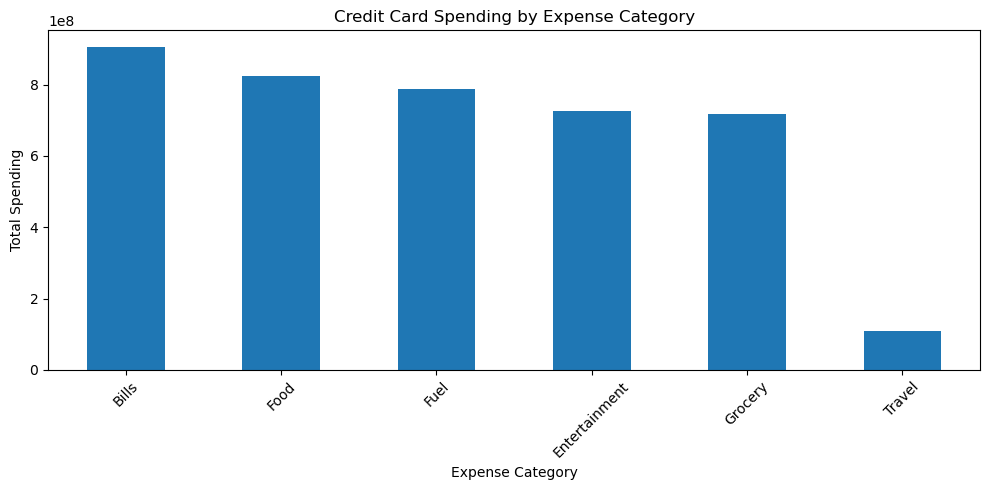

In [14]:
plt.figure(figsize=(10, 5))
category["Total Spending"].plot(kind="bar")
plt.title("Credit Card Spending by Expense Category")
plt.xlabel("Expense Category")
plt.ylabel("Total Spending")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 9. Spending by Card Type

In [15]:
card = cleaned_df.groupby("Card_Type")["Amount"].sum().sort_values(ascending=False)
card

Card_Type
Silver       1069613713
Signature    1013041105
Platinum     1007639019
Gold          984539536
Name: Amount, dtype: int64

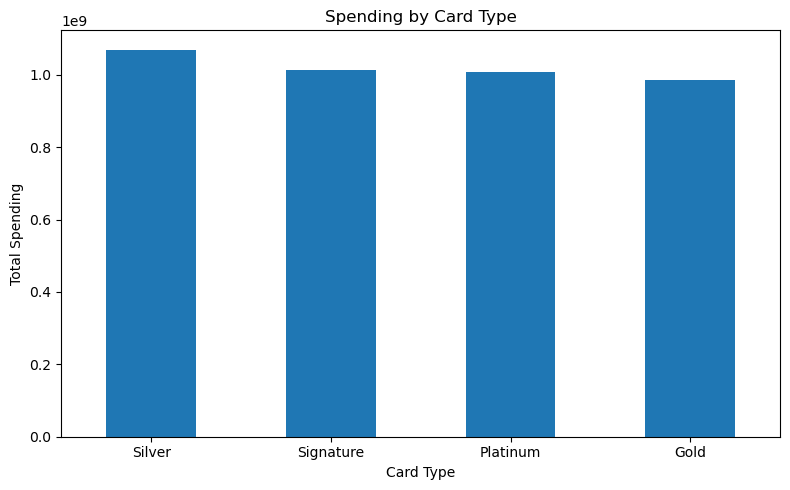

In [16]:
plt.figure(figsize=(8, 5))
card.plot(kind="bar")
plt.title("Spending by Card Type")
plt.xlabel("Card Type")
plt.ylabel("Total Spending")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 10. Spending by Gender

In [17]:
gender = cleaned_df.groupby("Gender")["Amount"].sum().sort_values(ascending=False)
gender

Gender
Female    2205311030
Male      1869522343
Name: Amount, dtype: int64

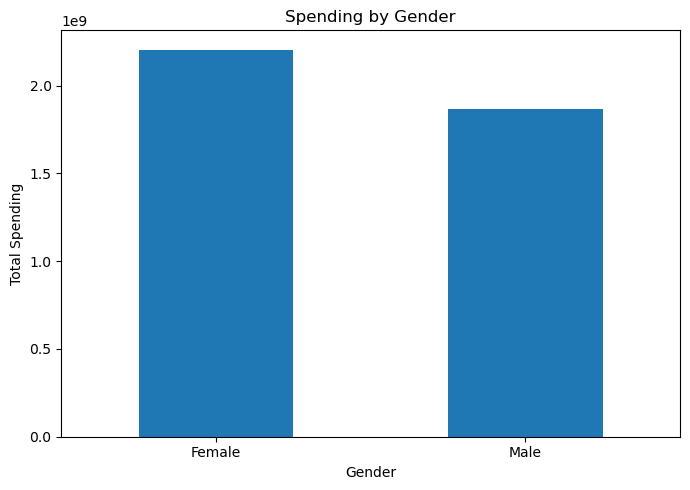

In [18]:
plt.figure(figsize=(7, 5))
gender.plot(kind="bar")
plt.title("Spending by Gender")
plt.xlabel("Gender")
plt.ylabel("Total Spending")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 11. Top 10 Cities by Spending

In [19]:
city = cleaned_df.groupby("City")["Amount"].sum().sort_values(ascending=False)
top_cities = city.head(10)
top_cities

City
Mumbai, India       576751476
Bengaluru, India    572326739
Ahmedabad, India    567794310
Delhi, India        556929212
Kolkata, India      115466943
Lucknow, India      115334476
Chennai, India      114730600
Hyderabad, India    114493477
Surat, India        114486151
Kanpur, India       114370532
Name: Amount, dtype: int64

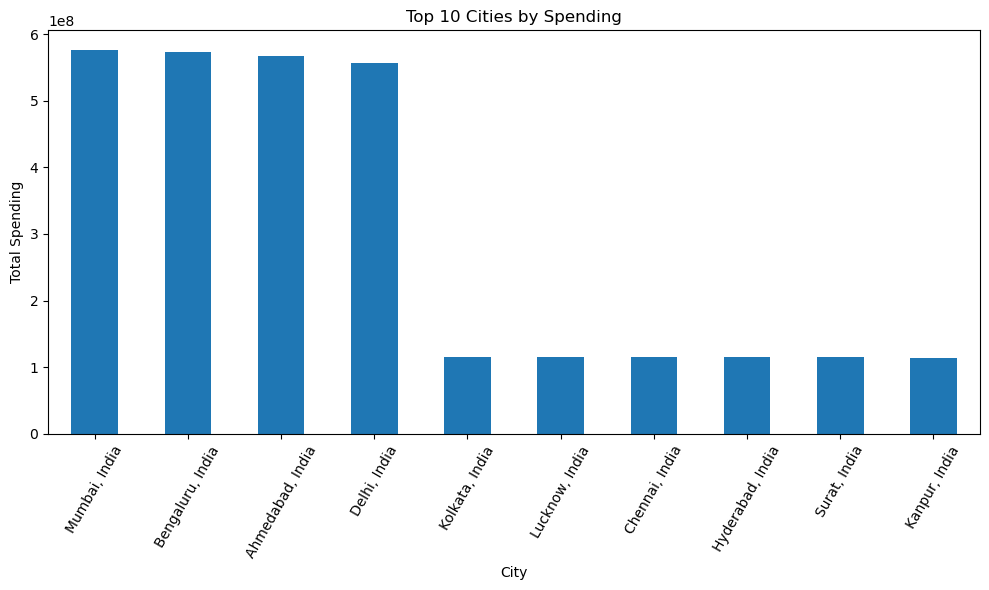

In [20]:
plt.figure(figsize=(10, 6))
top_cities.plot(kind="bar")
plt.title("Top 10 Cities by Spending")
plt.xlabel("City")
plt.ylabel("Total Spending")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

## 12. Monthly Spending Trend

In [21]:
monthly = (
    cleaned_df.assign(Month=cleaned_df["Date"].dt.to_period("M").astype(str))
    .groupby("Month")["Amount"]
    .sum()
)
monthly.head()

Month
2013-10    207360092
2013-11    192015963
2013-12    214267829
2014-01    207650982
2014-02    189220180
Name: Amount, dtype: int64

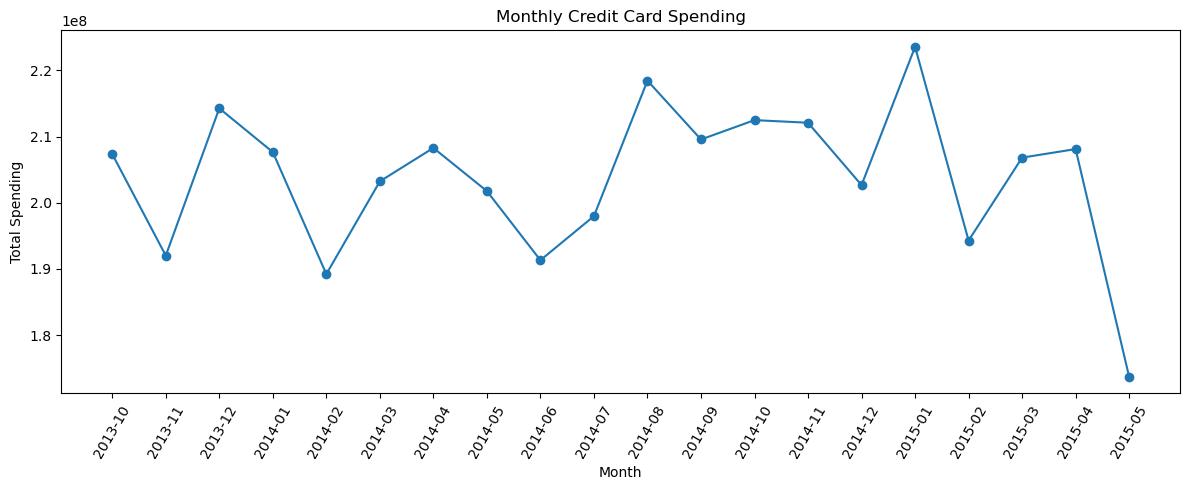

In [22]:
plt.figure(figsize=(12, 5))
plt.plot(monthly.index, monthly.values, marker="o")
plt.title("Monthly Credit Card Spending")
plt.xlabel("Month")
plt.ylabel("Total Spending")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

## 13. Category and Card Type Comparison

In [23]:
category_card = pd.pivot_table(
    cleaned_df,
    values="Amount",
    index="Expense_Type",
    columns="Card_Type",
    aggfunc="sum",
    fill_value=0
)
category_card

Card_Type,Gold,Platinum,Signature,Silver
Expense_Type,,,,
Bills,225533948,222027597,226115472,233395456
Entertainment,173468463,185608738,178648981,188711354
Food,193756454,210318810,206247814,214400931
Fuel,194343922,194069361,187797487,212925051
Grocery,166246853,171360820,186732315,193867935
Travel,31189896,24253693,27499036,26312986


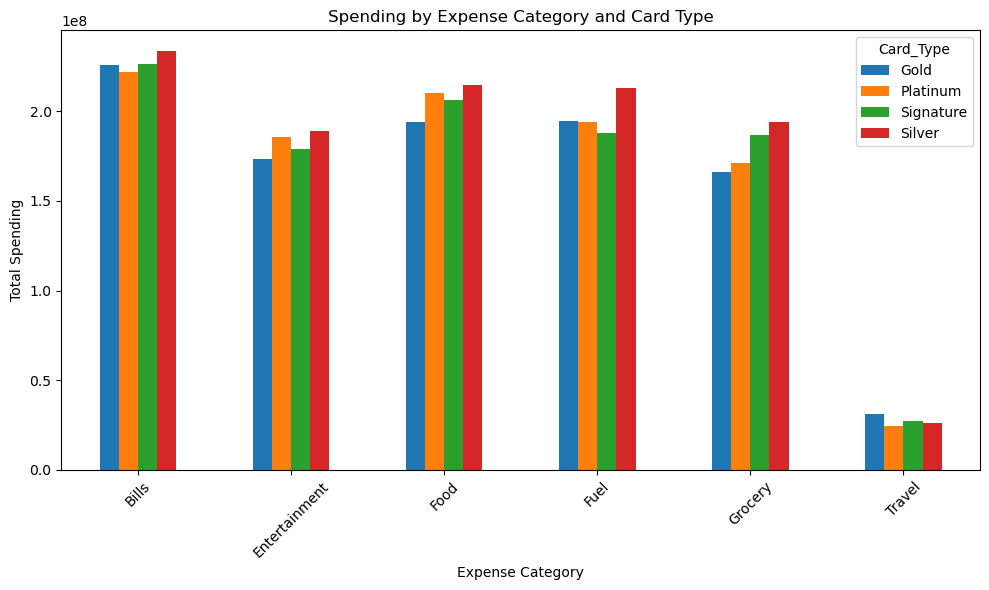

In [24]:
category_card.plot(kind="bar", figsize=(10, 6))
plt.title("Spending by Expense Category and Card Type")
plt.xlabel("Expense Category")
plt.ylabel("Total Spending")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

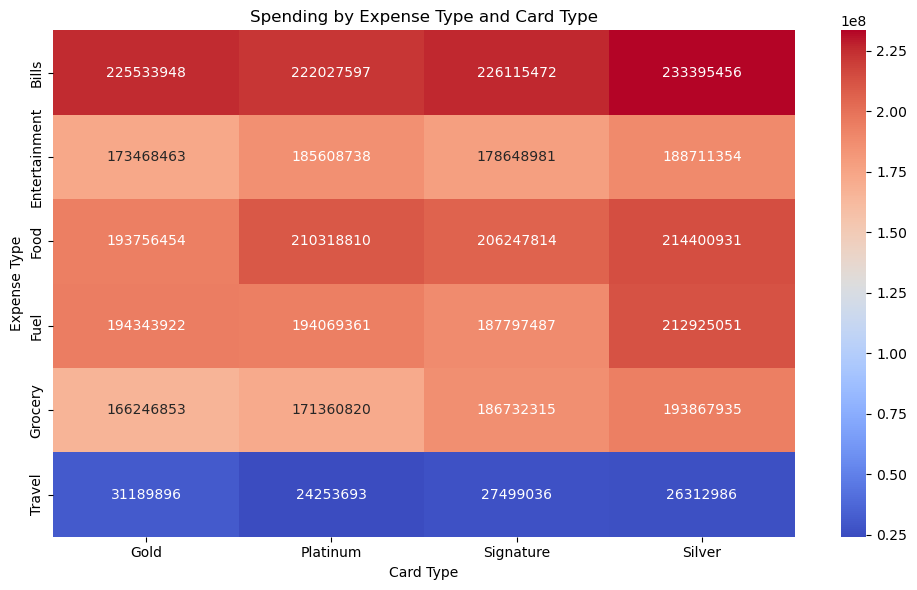

In [25]:
# seaborn heatmap for spending by expense type and card type

spending_heatmap = cleaned_df.pivot_table(
    values='Amount',
    index='Expense_Type',
    columns='Card_Type',
    aggfunc='sum'
)

plt.figure(figsize=(10, 6))

sns.heatmap(
    spending_heatmap,
    annot=True,
    fmt='.0f',
    cmap='coolwarm'
)

plt.title('Spending by Expense Type and Card Type')
plt.xlabel('Card Type')
plt.ylabel('Expense Type')
plt.tight_layout()
plt.show()

## 14. Final Cleaned Dataset Check

In [26]:
print("Final rows:", len(cleaned_df))
print("Final columns:", cleaned_df.columns.tolist())
print("Duplicate rows:", cleaned_df.duplicated().sum())
print("Missing values:")
print(cleaned_df.isnull().sum())

Final rows: 26052
Final columns: ['Transaction_ID', 'City', 'Date', 'Card_Type', 'Expense_Type', 'Gender', 'Amount']
Duplicate rows: 0
Missing values:
Transaction_ID    0
City              0
Date              0
Card_Type         0
Expense_Type      0
Gender            0
Amount            0
dtype: int64


CREDIT CARD SPENDING PATTERN ANALYSIS
===============================================================

Dataset Rows: 26052
Dataset Columns: 7

OVERALL ANALYSIS
---------------------------------------------------------------
Total Credit Card Spending: 4074833373.00
Average Transaction Amount: 156411.54
Total Transactions: 26052
Number of Expense Categories: 6

SPENDING BY CATEGORY
---------------------------------------------------------------
Bills: 907072473.00
Food: 824724009.00
Fuel: 789135821.00
Entertainment: 726437536.00
Grocery: 718207923.00
Travel: 109255611.00

TOP 10 CITIES BY AVERAGE CREDIT CARD SPENDING
---------------------------------------------------------------
Thodupuzha, India: 296684.00
Nahan, India: 264597.60
Alwar, India: 263488.67
Manendragarh, India: 257140.50
Vellore, India: 256179.00
Kashipur, India: 254690.75
Rewari, India: 253201.80
Yadgir, India: 249814.33
Kadapa, India: 249608.43
Viramgam, India: 246201.00

MONTHLY CREDIT CARD SPENDING
---------------------------------------------------------------
1: 431209556.00
2: 383512624.00
3: 410054446.00
4: 416394734.00
5: 375455609.00
6: 191321039.00
7: 197981416.00
8: 218453126.00
9: 209561433.00
10: 419846007.00
11: 404107968.00
12: 416935415.00

SPENDING BY CARD TYPE
---------------------------------------------------------------
Silver: 1069613713.00
Signature: 1013041105.00
Platinum: 1007639019.00
Gold: 984539536.00

CONCLUSION
---------------------------------------------------------------
The analysis summarizes 26052 credit card transactions and compares spending across expense categories, months, cities, and card types. Bills has the highest total spending among the expense categories, while month 1 has the highest total monthly spending. The generated outputs can be used for further SQL analysis and Power BI visualization.